In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv('prediction.csv')
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(['Salary Expectation ($)'], axis=1)
y = df['Salary Expectation ($)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MSE: 598478396.1605252
MAE: 21498.616672585154
RMSE: 24463.818102670015
R²: -0.003831756502382877


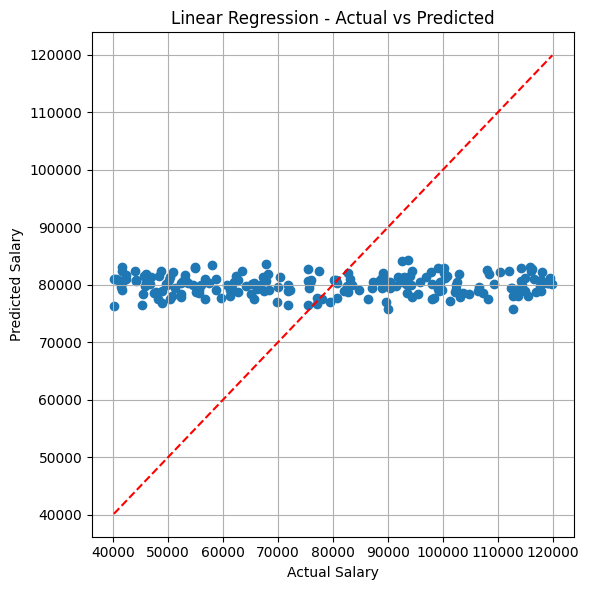

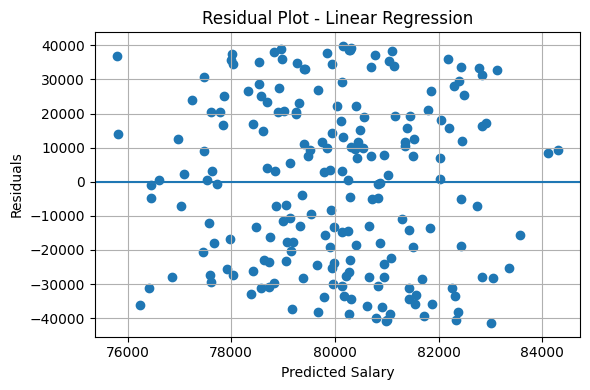

In [13]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Linear Regression - Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot (Recommended)
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

MSE: 643937370.10138
MAE: 21866.23053259855
RMSE: 25375.921069024866
R²: -0.08008039296545166


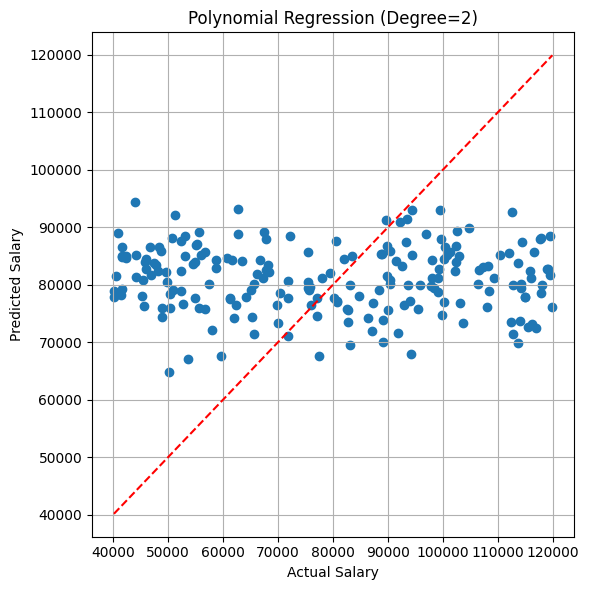

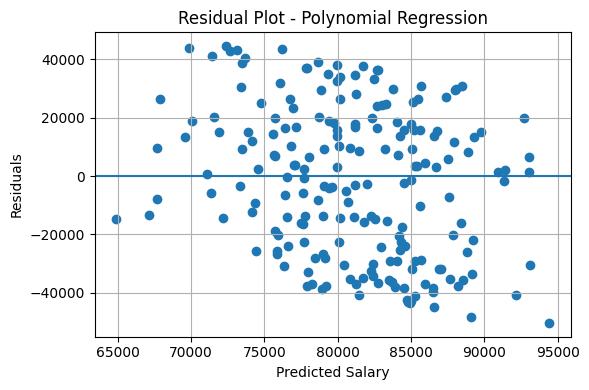

In [14]:
# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Create polynomial features
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Polynomial Regression (Degree=2)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Plot
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot - Polynomial Regression")
plt.grid(True)
plt.tight_layout()
plt.show()

MSE: 594734572.9395541
MAE: 21479.995283437394
RMSE: 24387.18050409998
R²: 0.002447782849500091


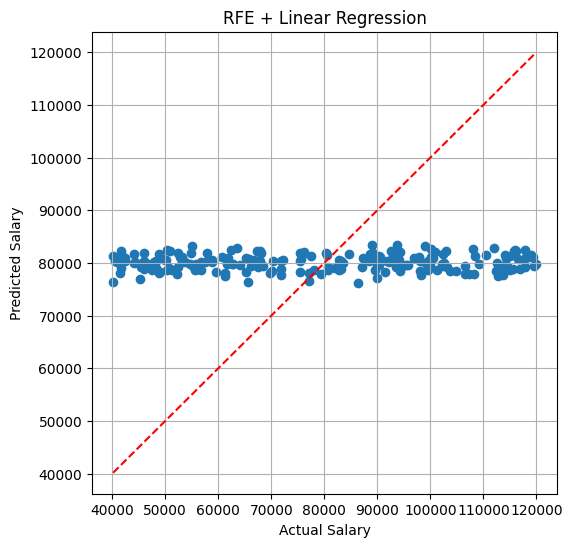

In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_rfe)
mae = mean_absolute_error(y_test, y_pred_rfe)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rfe)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rfe)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("RFE + Linear Regression")
plt.grid(True)
plt.show()

MSE: 632357545.9125088
MAE: 21558.574279404627
RMSE: 25146.72038084706
R²: -0.06065747756854312

Feature Importance:
              Feature  Importance
1                Name    0.215660
0           Resume_ID    0.210456
9    AI Score (0-100)    0.146875
3  Experience (Years)    0.132763
2              Skills    0.120069
5      Certifications    0.072140
8      Projects Count    0.057966
4           Education    0.023452
6            Job Role    0.020619
7  Recruiter Decision    0.000000


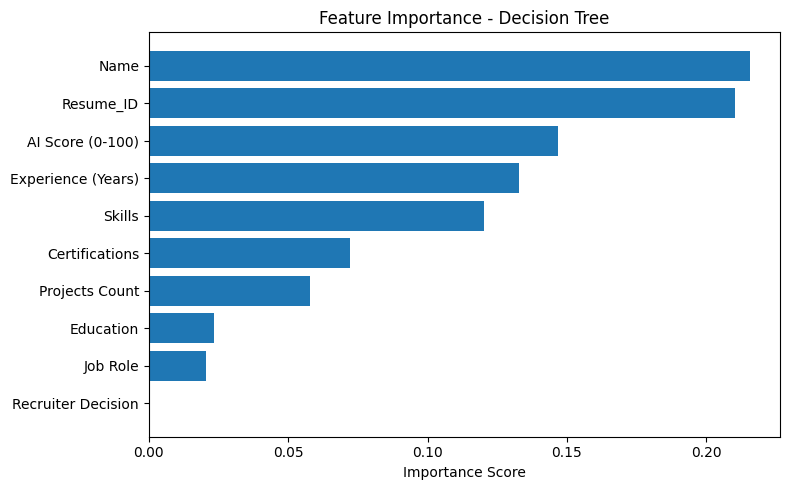

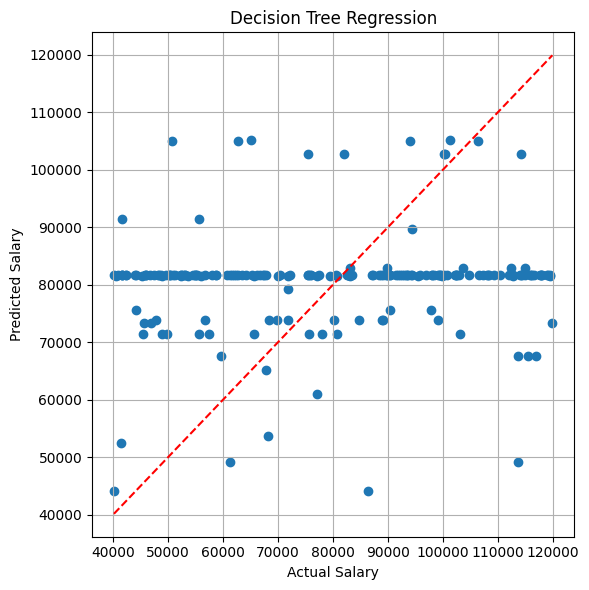

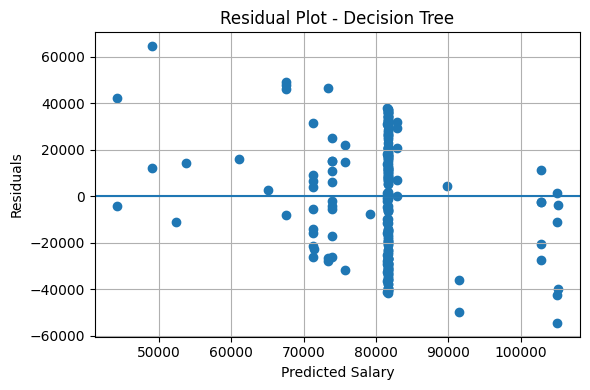

In [20]:
# Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Model with depth control
model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# =========================
# Feature Importance
# =========================
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# =========================
# Plot Feature Importance
# =========================
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# =========================
# Actual vs Predicted Plot
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Decision Tree Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Residual Plot
# =========================
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot - Decision Tree")
plt.grid(True)
plt.tight_layout()
plt.show()

MSE: 617446394.0368781
MAE: 21446.45055473771
RMSE: 24848.46864571091
R²: -0.03564690429669981

Feature Importance:
              Feature  Importance
0           Resume_ID    0.234259
1                Name    0.222449
2              Skills    0.170077
3  Experience (Years)    0.087123
8      Projects Count    0.079708
9    AI Score (0-100)    0.059582
5      Certifications    0.053053
4           Education    0.050993
6            Job Role    0.039511
7  Recruiter Decision    0.003246


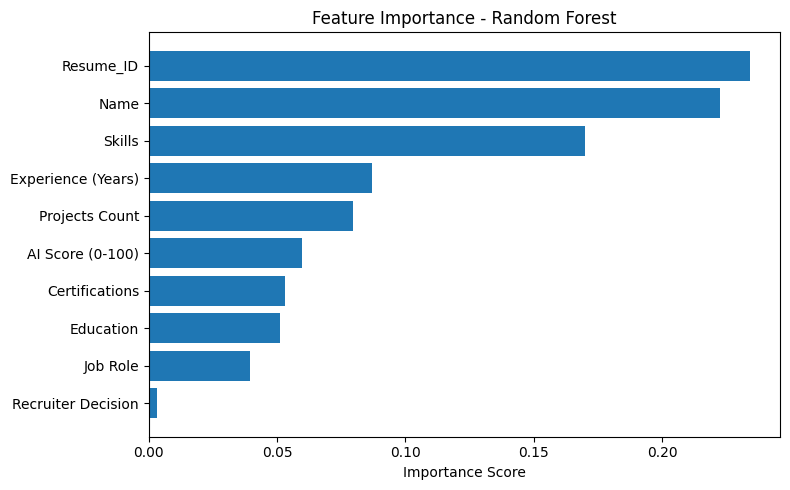

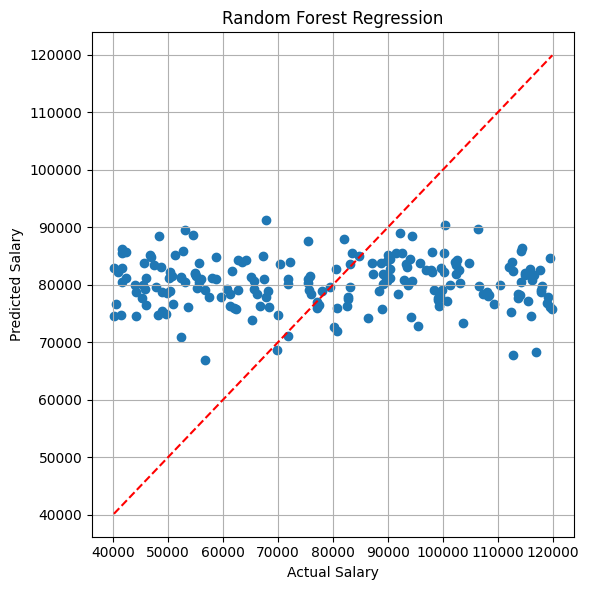

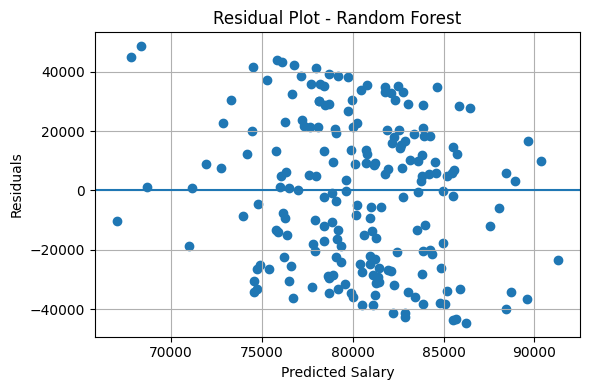

In [21]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Model with controlled complexity
model = RandomForestRegressor(
    n_estimators=200,       # number of trees
    max_depth=8,            # prevent overfitting
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1               # use all CPU cores
)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# =========================
# Evaluation Metrics
# =========================
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# =========================
# Feature Importance
# =========================
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# =========================
# Actual vs Predicted Plot
# =========================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Random Forest Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# Residual Plot
# =========================
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")
plt.grid(True)
plt.tight_layout()
plt.show()

MSE: 596566809.5262259
MAE: 21550.985437411255
RMSE: 24424.717184160516


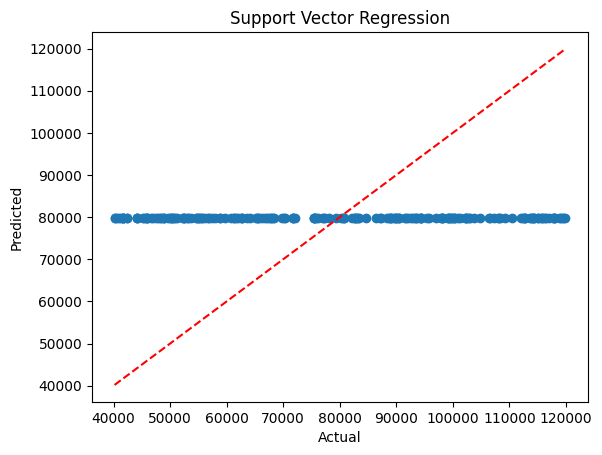

In [7]:
# Support Vector Regression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = SVR()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Support Vector Regression')
plt.show()

MSE: 598501085.8498392
MAE: 21499.873129503256
RMSE: 24464.281838015177


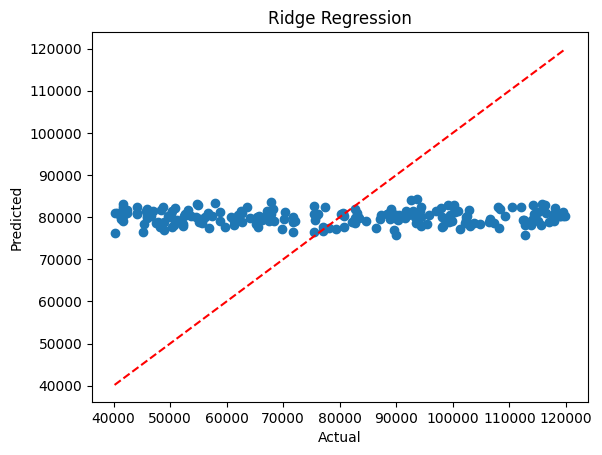

In [8]:
# Ridge Regression
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Ridge Regression')
plt.show()

MSE: 598486268.4431467
MAE: 21498.99421359735
RMSE: 24463.97899858375


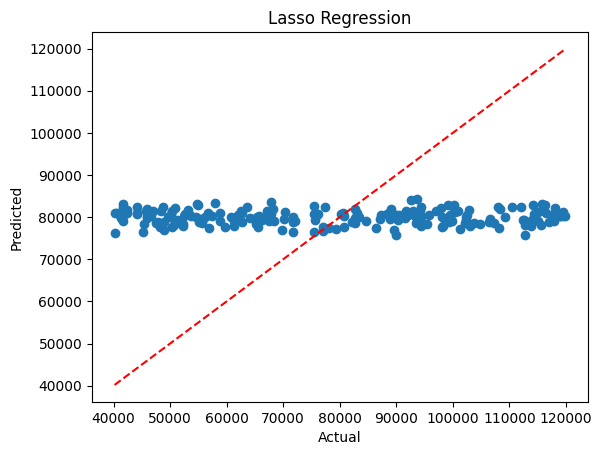

In [9]:
# Lasso Regression
from sklearn.linear_model import Lasso

model = Lasso(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Lasso Regression')
plt.show()

MSE: 599692005.4461727
MAE: 21552.406304609467
RMSE: 24488.60970831486


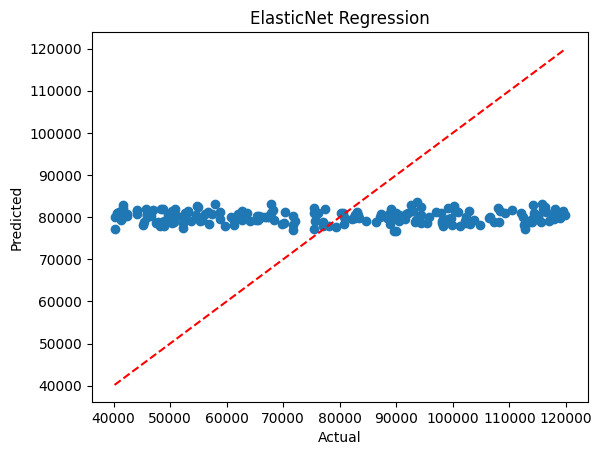

In [10]:
# ElasticNet Regression
from sklearn.linear_model import ElasticNet

model = ElasticNet(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('ElasticNet Regression')
plt.show()

MSE: 597308999.4916345
MAE: 21546.667324765353
RMSE: 24439.90588139886


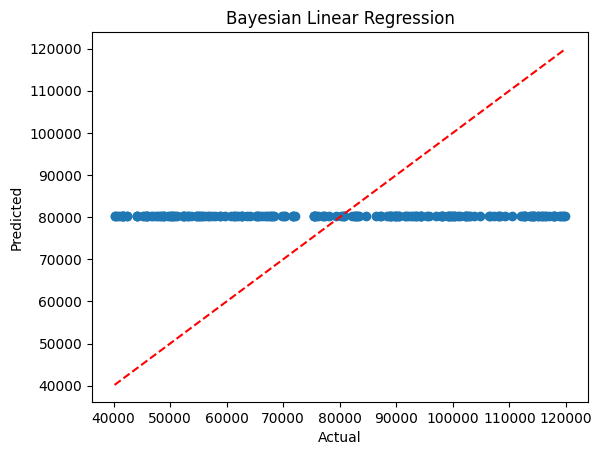

In [11]:
# Bayesian Linear Regression
from sklearn.linear_model import BayesianRidge

model = BayesianRidge()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Bayesian Linear Regression')
plt.show()